<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/03_heavy_tailed_slope_prior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 3 — Can heavy tails make a skeptical prior more robust?

In Notebook 2, a tight Normal prior on the population slope conflicted with information in the data.

Here we keep the same skeptical center and scale but replace the Normal prior with a heavier-tailed Student-t prior. The goal is to see whether changing only the tail behavior makes the prior more robust to data that favor a much larger effect.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy import stats
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering).

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helper

We will use the same participant-level predictive plot as in the previous notebooks.

In [4]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with observed data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

## 1. Change the tail behavior, not the skeptical center

### 1.1 How can we keep a skeptical prior but make it less brittle?

Notebook 2 concentrated the slope prior tightly around zero. How can we preserve that skepticism near zero while allowing rare, much larger slopes?

We can replace the Normal prior with a **heavy-tailed Student-t prior** that has the same center and scale.

We will use

$$
b_1 \sim \operatorname{StudentT}(\nu=7,\mu=0,\sigma=1).
$$

Near zero this resembles the `Normal(0, 1)` prior from Notebook 2, but its heavier tails assign substantially more probability to large positive or negative slopes.

### 1.2 How does the Student-t prior differ from the Normal prior?

The next cell plots the two prior densities using the same center and scale.

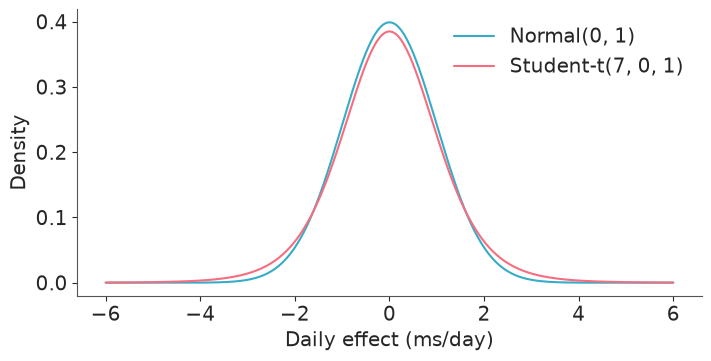

In [5]:
x = np.linspace(-6, 6, 800)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(x, stats.norm.pdf(x, 0, 1), label="Normal(0, 1)")
ax.plot(x, stats.t.pdf(x, df=7), label="Student-t(7, 0, 1)")
ax.set(xlabel="Daily effect (ms/day)", ylabel="Density")
ax.legend(frameon=False)
plt.show()

Where is the difference between the two priors most important?

The two distributions are similar around zero, but the Student-t puts much more probability in the tails. Large slopes are still unusual under the Student-t prior, but they are no longer nearly impossible.

### 1.3 Build the model with the heavy-tailed slope prior.

Use the same data, likelihood, and priors for `b0` and `sd_y` as before. Use `pm.StudentT` for `b1`.

In [6]:
mu_b0 = 250
sd_b0 = 100

mu_b1 = 0
sd_b1 = 1
nu_b1 = 7

mu_sd_y = 50

In [7]:
coords = {"obs_id": np.arange(len(sleep))}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0)
    b1 = pm.StudentT("b1", nu=nu_b1, mu=mu_b1, sigma=sd_b1)
    sd_y = pm.Exponential("sd_y", scale=mu_sd_y)

    mu = pm.Deterministic("mu", b0 + b1 * days, dims="obs_id")

    y = pm.Normal(
        "y",
        mu=mu,
        sigma=sd_y,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

## 2. Prior predictive check — Does the heavy-tailed prior look acceptable before fitting?

### 2.1 Generate prior predictive reaction times.

Draw 500 samples from the prior predictive distribution for `y`.

In [8]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, sd_y, y]


### 2.2 Plot the prior predictive reaction times.

Use the supplied `plot_participants` function.

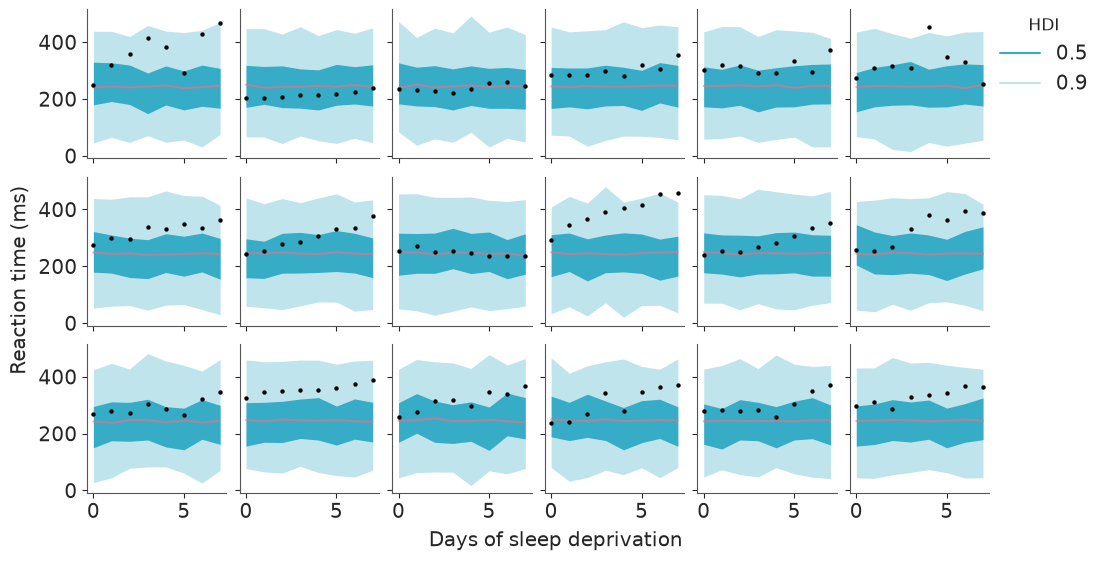

In [9]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.3 Do the prior predictive simulations meet the criteria established in Notebook 1?

Apply the same criteria used in the previous notebooks. In particular, does the prior put enough probability on substantial changes across the seven days without routinely generating absurd trajectories?

Not convincingly. The central prior predictive bands still favor trajectories with relatively little systematic change across days.

The heavy tails make much larger slopes possible, but those slopes are rare and therefore do not dominate the 50% or 90% prior predictive intervals. The prior predictive check still gives us reason to be cautious.

### 2.4 Does the prior predictive plot look very different from Notebook 2?

No. The central predictive intervals look quite similar because the two slope priors have the same center and scale near zero.

Their important difference lies in rare tail values, which are not emphasized by 50% and 90% HDIs.

## 3. Fit and diagnose — Can the model sample reliably?

### 3.1 Fit the model.

Use the same sampling settings as before: 1000 posterior draws in each of 4 chains after 1500 tuning draws.

In [10]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [b0, b1, sd_y]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 26 seconds.


### 3.2 Check the sampling diagnostics.

Count divergences, summarize `b0`, `b1`, and `sd_y`, and inspect their trace/distribution plots using the criteria established in Notebook 1.

In [11]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

azs.summary(
    idata,
    var_names=["b0", "b1", "sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0,279.44,9.42,264.64,295.62,1397.49,1456.45,1.0,0.25,0.18
b1,8.16,2.39,4.26,12.10,1298.74,1697.70,1.0,0.07,0.04
sd_y,51.80,3.23,46.80,57.09,2026.94,2102.41,1.0,0.07,0.06


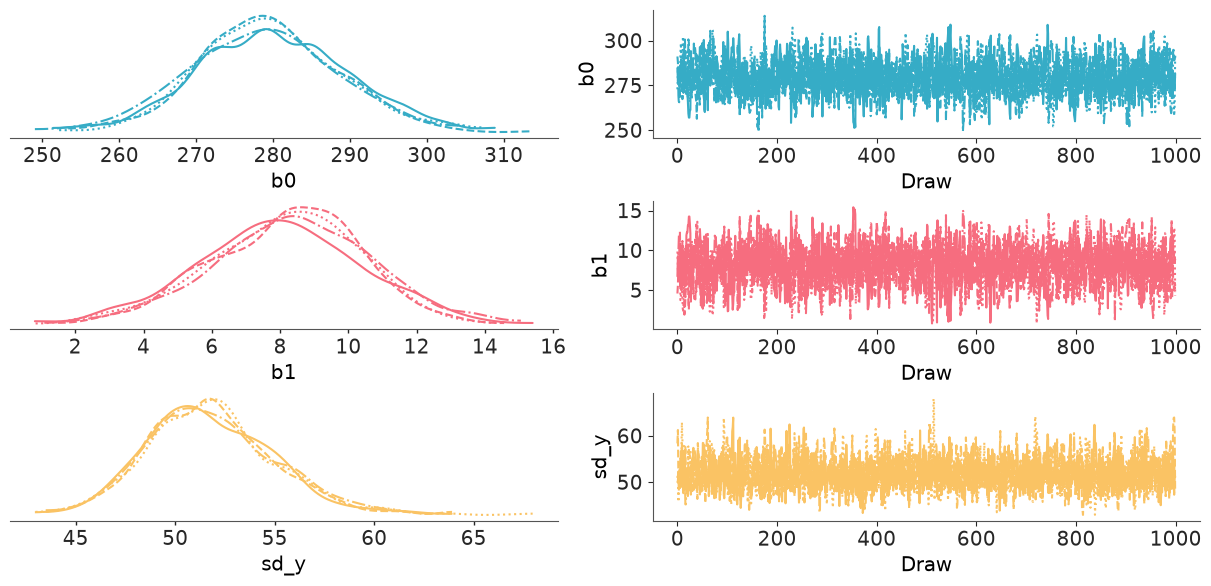

In [12]:
azp.plot_trace_dist(idata, var_names=["b0", "b1", "sd_y"]);

### 3.3 Did sampling succeed?

Do the numerical and graphical diagnostics indicate that the posterior samples are computationally reliable?

Yes. The chains mix well, there are no divergences, and R-hat and effective sample sizes are satisfactory.

As in Notebook 2, successful sampling does not by itself tell us whether the prior or the model is scientifically appropriate.

## 4. Posterior predictive check — Did the heavier tails improve model fit?

### 4.1 Generate and plot posterior predictive reaction times.

Generate replicated values of `y` from the fitted model and compare them with the observations using `plot_participants`.

Sampling: [y]


Output()

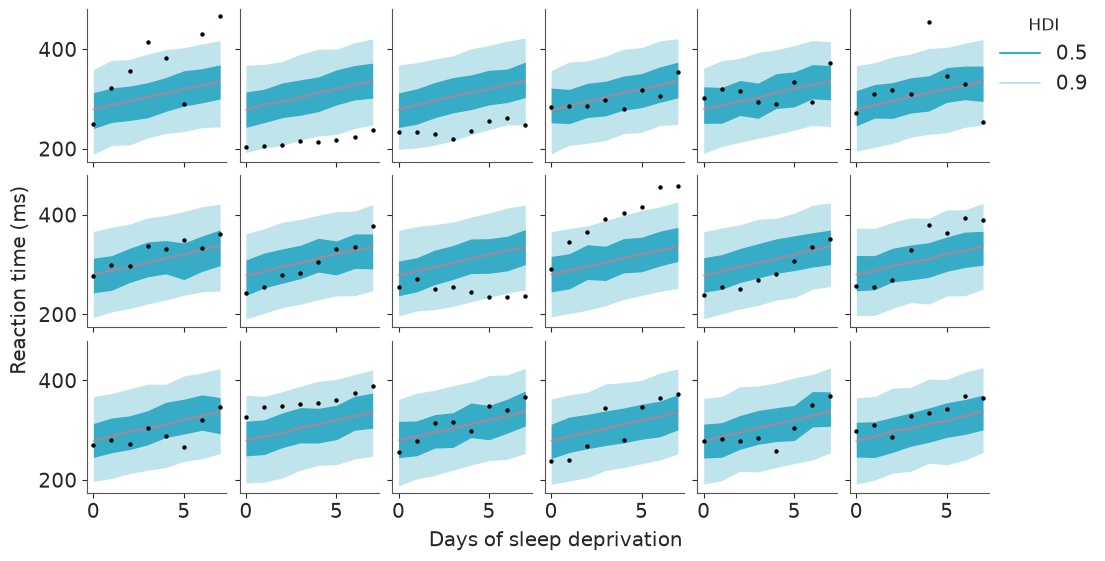

In [13]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 4.2 Does the fitted model now meet the posterior predictive criteria from Notebook 1?

Not fully. The model does a much better job of reproducing the increase in reaction time across days, but it still cannot reproduce the persistent differences among participants because it has only one population intercept and one population slope.

### 4.3 Compared with Notebook 2, did changing only the prior tails improve the model's ability to reproduce the systematic increase across days?

Yes. The heavier-tailed prior allows the posterior slope to move much farther away from zero, so the posterior predictive trajectories show a substantially stronger increase across days than they did under the tight Normal prior.

## 5. Prior sensitivity — Did the heavy tails eliminate the prior–data conflict?

### 5.1 Why check prior sensitivity if the posterior predictive fit improved?

Improved prediction does not tell us whether the prior and likelihood are now in agreement.

Power-scaling sensitivity lets us ask whether small changes in the weight of the prior or likelihood still move the posterior substantially. That directly tests whether the prior–data conflict seen in Notebook 2 has actually been resolved.

### 5.2 Prepare the information required for power-scaling.

The bookkeeping code is supplied.

In [14]:
with model:
    pm.compute_log_likelihood(idata)
    compute_log_density(
        idata,
        model=model,
        kind="prior",
        extend_inferencedata=True,
    )

Output()

Output()

### 5.3 Calculate and visualize prior sensitivity.

Use `azs.psense_summary` and `azp.plot_psense_dist` for `b0`, `b1`, and `sd_y`.

In [15]:
azs.psense_summary(idata, var_names=["b0", "b1", "sd_y"])

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
b0,0.335,0.416,potential prior-data conflict
b1,0.393,0.477,potential prior-data conflict
sd_y,0.108,0.249,potential prior-data conflict


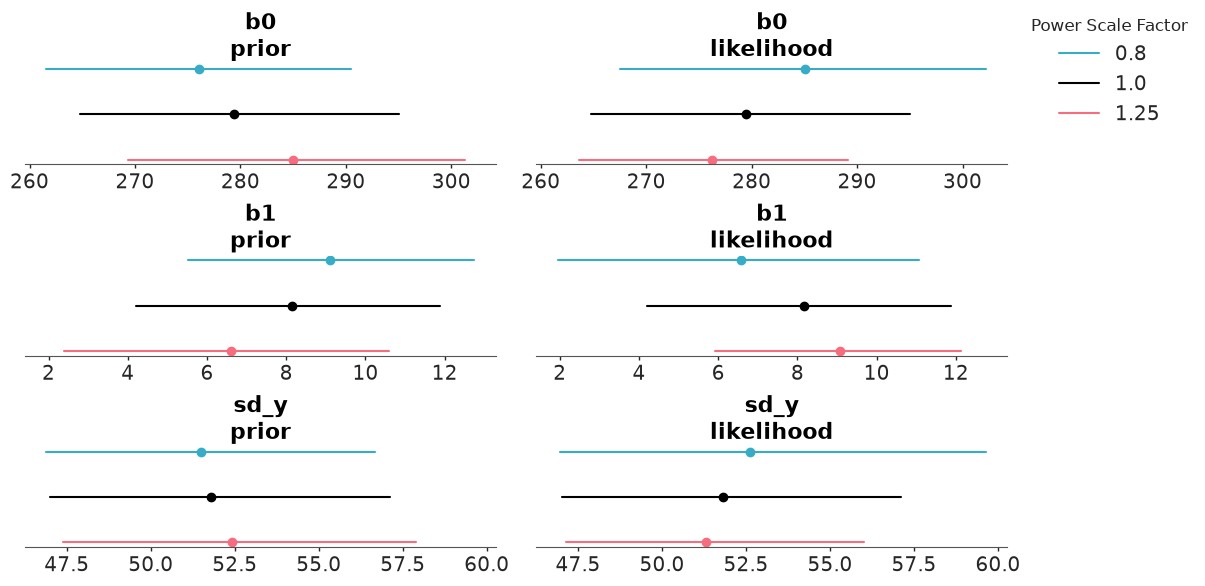

In [16]:
azp.plot_psense_dist(
    idata,
    var_names=["b0", "b1", "sd_y"],
    visuals={"dist": False},
);

### 5.4 Did the heavy-tailed prior eliminate the prior–data conflict?

Does the sensitivity analysis still flag a problem?

No. The sensitivity analysis still flags prior–data conflict.

The heavier tails make the skeptical prior less brittle and substantially improve the fitted trend, but they do not make the prior fully compatible with the information in the data.